Ce notebook crée des hexagones concentriques itérativement sur base d'un nombre d'anneaux

In [1]:
import re
import os
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.path import Path
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as colors

9.998796857129712


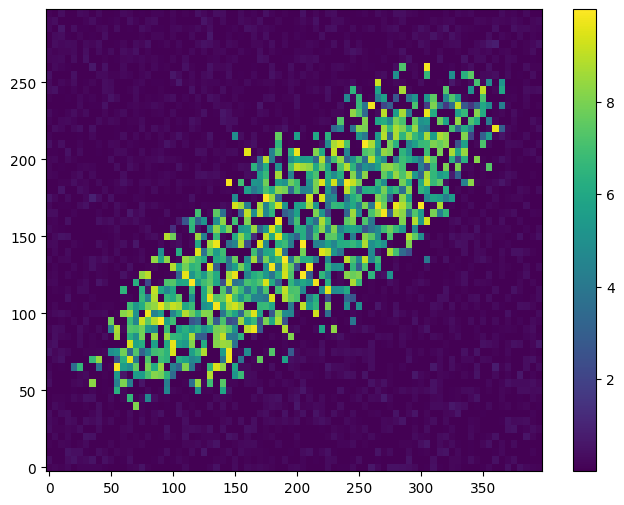

Nnodes =  144000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Grid
Lx = 400
Ly = 300
dx = 5
dy = 5
NY = int(Ly/dy)
NX = int(Lx/dx)
x = np.arange(0, Lx, dx)
y = np.arange(0, Ly, dy)
X, Y = np.meshgrid(x, y)

# Ellipse parameters
xc, yc = Lx/2, Ly/2
a, b = 180, 50
theta = np.deg2rad(30)

Xc = X - xc
Yc = Y - yc
X_rot =  Xc * np.cos(theta) + Yc * np.sin(theta)
Y_rot = -Xc * np.sin(theta) + Yc * np.cos(theta)

# Add boundary noise
noise_amp = 12
angle = np.arctan2(Y_rot, X_rot)
a_perturbed = a + noise_amp * np.random.randn(*angle.shape)
b_perturbed = b + noise_amp * np.random.randn(*angle.shape)

# Ellipse mask
ellipse_mask = (X_rot/a_perturbed)**2 + (Y_rot/b_perturbed)**2 <= 1

# Distance to ellipse boundary (approximate)
distance = np.sqrt((X_rot/a_perturbed)**2 + (Y_rot/b_perturbed)**2)
# Create fading factor: 1 inside, decays to 0 near boundary
fade_width = 1 # fraction of ellipse radius
fade_factor = np.clip(1 - (distance - 10)/fade_width, 0, 1)

# Base lognormal field
mu, sigma = 2.0, 0.3
Z = np.zeros_like(X, dtype=float)
Z[ellipse_mask] = np.random.lognormal(mu, sigma, size=np.sum(ellipse_mask))
Z[~ellipse_mask] = np.random.normal(0.07, 0.2, size=np.sum(~ellipse_mask))

# Additional multiplicative noise
Z[ellipse_mask] *= 1 + 0.3 * np.random.randn(np.sum(ellipse_mask))
Z[ellipse_mask] = np.clip(Z[ellipse_mask], 0, None)

# Apply fading at the boundary
Z *= fade_factor

Z[Z>10] = 0.01
Z[Z<=0.01] = 0.01
print(Z.max())
Z = Z / 270
# Z = Z * 0 + 1

# Plot
plt.figure(figsize=(8,6))
plt.pcolormesh(X, Y, Z, shading='auto')
plt.colorbar()

plt.show()

out = open("U_dist.dat","w")
out.write("#Generated Uranium distribution\n\n")
out.write(f"# NX = {NX}\n")
out.write(f"# NY = {NY}\n")
out.write("# column 1: node-number\n")
out.write("# column 2: x-distance\n")
out.write("# column 3: y-distance\n")
out.write('# column 4: Uraninite\n\n')
c = 0
for j in range(NY):
    y = dy/2+j*dy
    for i in range(NX):
        x = dx/2+i*dx
        out.write(f"{c} {x} {y} {Z[j,i]:.3f}\n")
        c = c + 1
out.close()

print("Nnodes = ", NX*NY*30)

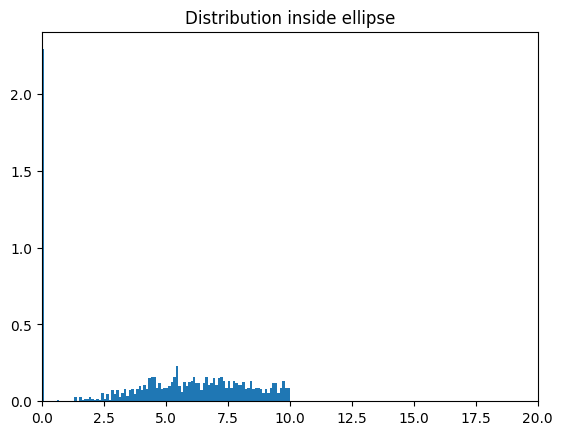

In [10]:
values_inside = Z[ellipse_mask]
plt.figure()
plt.hist(values_inside, bins=100, density=True)
plt.title("Distribution inside ellipse")
plt.xlim(0,20)
plt.show()